In [31]:
%matplotlib inline
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.interpolate import CubicSpline

**Methodology**

Estimating Total Daily Energy Expenditure (TDEE) from real-world tracking data is
complicated by two factors that standard formulas ignore: missing/irregular log
entries, and the fact that TDEE is not constant — it shifts as body weight changes
during sustained caloric surplus or deficit. Rather than relying on a static
predictive equation, this project estimates TDEE directly from observed weight and
caloric intake data using a numerical pipeline built around four stages:

1.) **Data Preparation** — Raw daily weight contains missing entries
   due to inconsistent tracking. These gaps are filled using interpolation, with
   linear and cubic spline methods compared quantitatively (using held-out error) to
   select the more appropriate method for this dataset.

2.) **Phase Detection** — Weight trajectories over long tracking periods consist of
   alternating bulk (surplus) and cut (deficit) phases. Phase boundaries are
   identified numerically: a polynomial is fit to the weight data, its derivative is
   computed using a 5-point finite-difference stencil, and sign changes in this
   derivative mark transitions between phases.

3.) **Piecewise Polynomial Regression** — Rather than fitting a single global curve
   (which risks Runge's-phenomenon-style instability and forces unrelated phases to
   influence each other's fit) or a single straight line per phase (which cannot
   capture the deceleration caused by adaptive TDEE), each detected phase is fit
   independently with a low-order polynomial via least-squares (normal equations).
   The degree of each polynomial is chosen automatically using the Bayesian
   Information Criterion (BIC), which balances fit quality against model
   complexity to avoid overfitting to daily noise.

4.) **TDEE Estimation** — For each phase, the average rate of weight change is
   computed exactly from the fitted curve using the Mean Value Theorem (average
   slope = total change in the fitted curve over the segment, divided by segment
   duration). Combined with the average caloric intake for that phase and the
   standard approximation that ~7700 kcal corresponds to 1 kg of body mass, this
   yields an estimated TDEE for each phase.

**`merger()`** — Loads raw calorie and weight CSV logs, aggregates them to daily
  granularity, and merges them onto a complete date range (so missing days appear
  explicitly as `NaN` rather than being silently dropped).

In [32]:
def merger(pathCal, pathMass):
    df1 = pd.read_csv(pathCal)
    df2 = pd.read_csv(pathMass)

    df1["Date"] = pd.to_datetime(df1["Date"])
    df2["Date"] = pd.to_datetime(df2["Date"])

    daily_calories = df1.groupby("Date", as_index=False)["Calories"].sum()
    daily_calories["Calories"] = np.ceil(daily_calories["Calories"]).astype(int)

    daily_weight = df2.groupby("Date", as_index=False)["Weight"].mean()

    all_dates = pd.DataFrame({
        "Date": pd.date_range(
            start=min(df1["Date"].min(), df2["Date"].min()),
            end=max(df1["Date"].max(), df2["Date"].max())
        )
    })

    merged_df = all_dates \
        .merge(daily_calories, on="Date", how="left") \
        .merge(daily_weight, on="Date", how="left")

    merged_df["day"] = (merged_df["Date"] - merged_df["Date"].min()).dt.days

    return merged_df

calories_data = "Calories.csv"
weight_data = "Weight.csv"
merger(calories_data,weight_data).to_csv("output.csv", index = False)


**`interpolate_and_compare()`** — For each of weight and calories, a subset of
  known values is held out, and both linear interpolation (`np.interp`) and cubic
  spline interpolation (scipy's cubic spline) are used to predict the
  held-out values. Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) are
  computed for both methods to justify which is used to fill the full dataset.


── Weight Interpolation ──
  Linear → MAE: 0.366,  RMSE: 0.483
  Spline → MAE: 0.536,  RMSE: 0.713


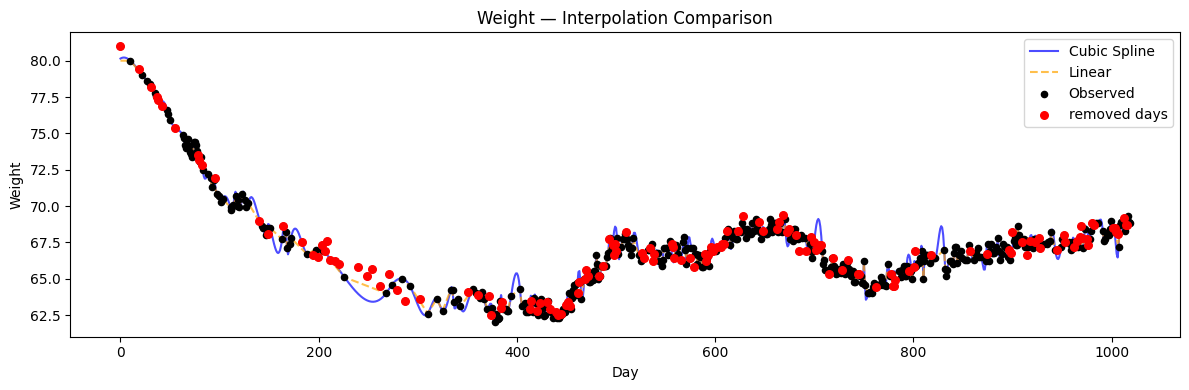


── Calories Interpolation ──
  Linear → MAE: 224.242,  RMSE: 292.961
  Spline → MAE: 273.524,  RMSE: 362.314


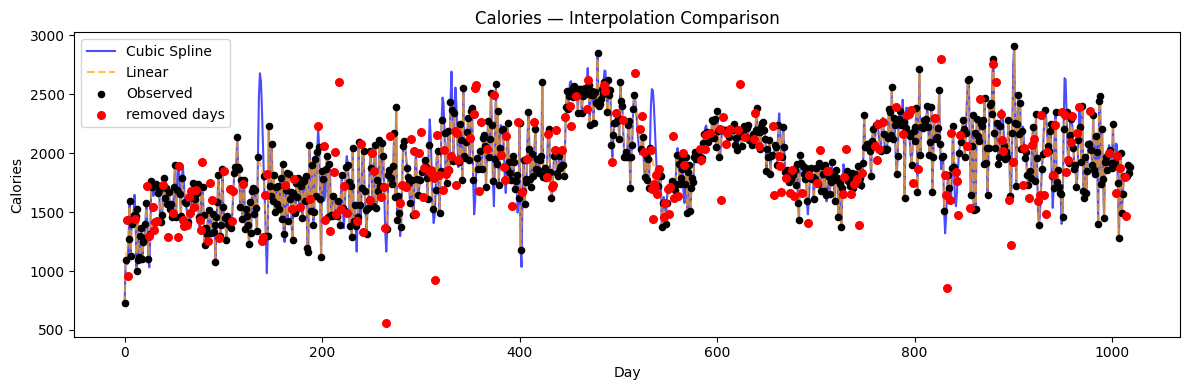

In [33]:
def interpolate_and_compare(df):
    results = {}

    for column in ["Weight", "Calories"]:
        known = df[df[column].notna()].copy()
        days = known["day"].values
        values = known[column].values

        # remove 25% for error comparison
        np.random.seed(42)
        test_idx = np.sort(np.random.choice(len(days), size=len(days)//4, replace=False))
        train_days = np.delete(days, test_idx)
        train_values = np.delete(values, test_idx)
        test_days = days[test_idx]
        true_values = values[test_idx]

        # Linear
        linear_pred = np.interp(test_days, train_days, train_values)

        # Cubic spline
        cs = CubicSpline(train_days, train_values)
        spline_pred = cs(test_days)

        # Errors
        linear_mae  = np.mean(np.abs(linear_pred - true_values))
        spline_mae  = np.mean(np.abs(spline_pred - true_values))
        linear_rmse = np.sqrt(np.mean((linear_pred - true_values) ** 2))
        spline_rmse = np.sqrt(np.mean((spline_pred - true_values) ** 2))

        print(f"\n── {column} Interpolation ──")
        print(f"  Linear → MAE: {linear_mae:.3f},  RMSE: {linear_rmse:.3f}")
        print(f"  Spline → MAE: {spline_mae:.3f},  RMSE: {spline_rmse:.3f}")

        # Fill all days using both methods
        all_days = df["day"].values
        df[f"{column}_linear"] = np.interp(all_days, train_days, train_values)
        df[f"{column}_spline"] = cs(all_days)

        results[column] = {
            "linear_mae": linear_mae, "spline_mae": spline_mae,
            "linear_rmse": linear_rmse, "spline_rmse": spline_rmse,
            "spline_fn": cs
        }

        # Plot
        plt.figure(figsize=(12, 4))
        plt.plot(all_days, df[f"{column}_spline"], label="Cubic Spline", color="blue", alpha=0.7)
        plt.plot(all_days, df[f"{column}_linear"], label="Linear",       color="orange", alpha=0.7, linestyle="--")
        plt.scatter(days, values, label="Observed", color="black", zorder=5, s=20)
        plt.scatter(test_days, true_values, label="removed days", color="red", zorder=6, s=30)
        plt.xlabel("Day")
        plt.ylabel(column)
        plt.title(f"{column} — Interpolation Comparison")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return df, results

df1 = pd.read_csv("output.csv")
df2, results = interpolate_and_compare(df1)
df2.to_csv("spline.csv", index = False)

**Interpolation method selection.** Linear interpolation outperformed cubic spline
on this dataset (lower MAE and RMSE on held-out points). This suggests that within a given phase,
day-to-day weight change is close to linear, and the additional
curvature offered by cubic splines mostly fits short-term noise (e.g. water
retention).

**`detect_phases()`** - Fits a polynomial (degree selected via BIC) to the
  interpolated weight series, computes its derivative using a 5-point stencil
  finite-difference formula, and classifies each day as "bulk" or "cut" based on
  the sign of the local slope. This allows for clear phase boundaries which we can split into seperate phases.

**`differentiate()`** - Using the 5-point-stencil formula to find derivative.

**`best_degree()`** - using Bayesian Information Criterion formula (n·ln(SSE/n) + k·ln(n)) to find the best degree.

In [34]:
#Helper functions

def differentiate(f, x, h=0.01):
    """5-point stencil"""
    return (f(x - 2*h) - 8*f(x - h) + 8*f(x + h) - f(x + 2*h)) / (12*h)

def best_degree(xs, ys, max_degree=15, verbose=False):
    n = len(ys)
    max_degree = min(max_degree, n - 1)
    best_deg = 1
    best_bic = np.inf
    scores = {}

    for deg in range(1, max_degree + 1):
        coeffs = np.polyfit(xs, ys, deg)
        f = np.poly1d(coeffs)
        residuals = ys - f(xs)
        sse = np.sum(residuals ** 2)
        if sse <= 0:
            continue #avoid log(0)
        bic = n * np.log(sse / n) + deg * np.log(n)
        scores[deg] = bic

        if bic < best_bic:
            best_bic = bic
            best_deg = deg

    if verbose:
        for d, b in scores.items():
            print(f"  deg {d}: BIC = {b:.3f}")

    return best_deg


Phase transitions:
  2023-09-23  bulk > cut
  2024-09-12  cut > bulk
  2025-05-29  bulk > cut
  2025-10-29  cut > bulk


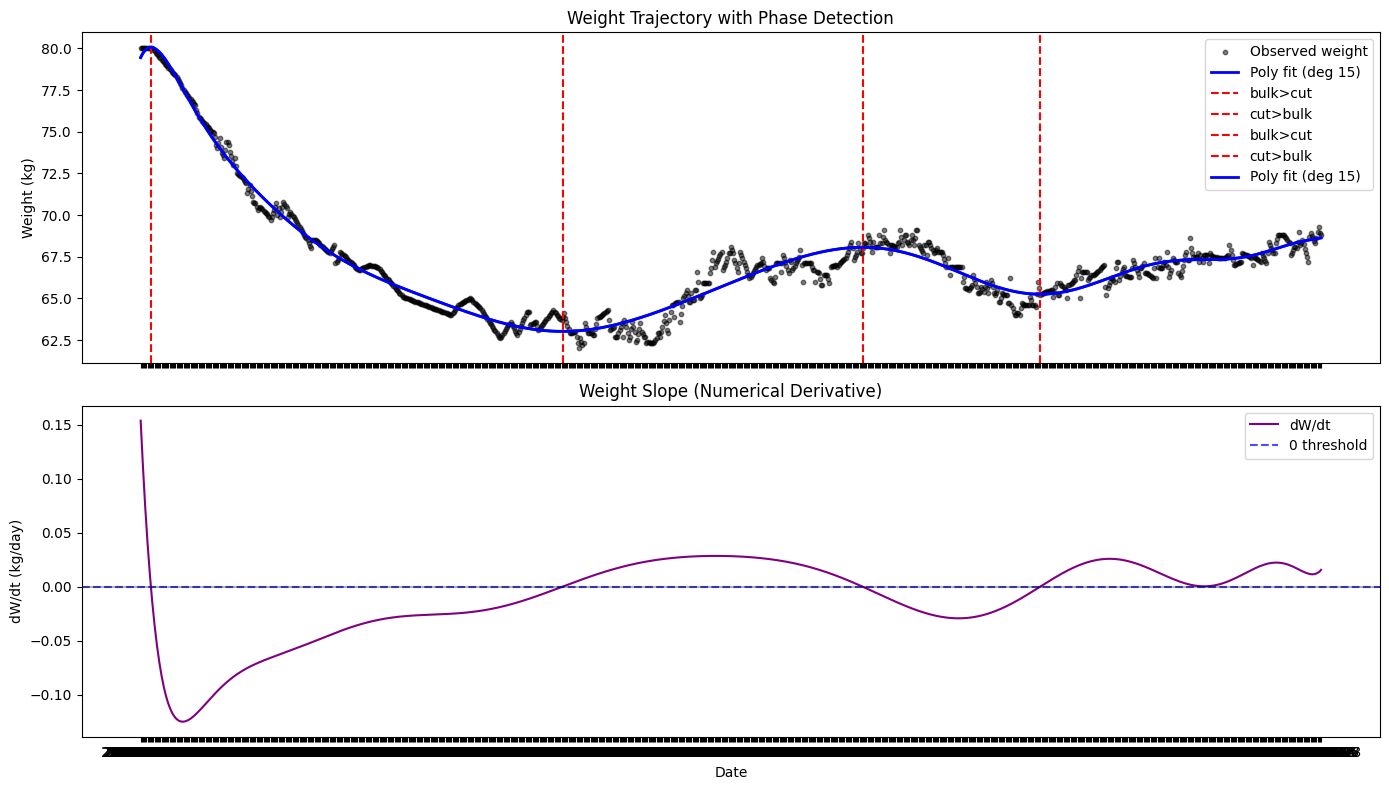

In [35]:
def detect_phases(df, slope_threshold=0):
    days = df["day"].values.astype(float)
    weight = df["Weight_linear"].values

    # Fit best polynomial to weight
    degree = best_degree(days, weight)
    coeffs = np.polyfit(days, weight, degree)
    f = np.poly1d(coeffs)

    # derivative at each day
    x = np.linspace(days.min(), days.max(), len(days))
    d = differentiate(f, x)

    # Classify each day
    phases = []
    for slope in d:
        if slope > slope_threshold:
            phases.append("bulk")
        elif slope < -slope_threshold:
            phases.append("cut")
        else:
            phases.append("maintenance")

    df["phase"] = phases
    df["fitted_weight"] = f(x)
    df["weight_slope"] = d

    # Find transition points (where phase changes)
    transitions = []
    for i in range(1, len(phases)):
        if phases[i] != phases[i-1]:
            transitions.append((df["Date"].iloc[i], phases[i-1], phases[i]))

    print("\nPhase transitions:")
    for date, prev, curr in transitions:
        print(f"  {date}  {prev} > {curr}")

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Weight + fitted curve
    ax1.scatter(df["Date"], df["Weight_linear"], color="black", s=10, alpha=0.5, label="Observed weight")
    ax1.plot(df["Date"], df["fitted_weight"], color="blue", linewidth=2, label=f"Poly fit (deg {degree})")

    # Vertical lines at transition points
    for date, prev, curr in transitions:
        ax1.axvline(x=date, color="red", linestyle="--", linewidth=1.5, label=f"{prev}>{curr}")

    ax1.set_ylabel("Weight (kg)")
    ax1.set_title("Weight Trajectory with Phase Detection")
    ax1.legend()
    ax1.plot(df["Date"], df["fitted_weight"], color="blue", linewidth=2, label=f"Poly fit (deg {degree})")
    ax1.set_ylabel("Weight (kg)")
    ax1.set_title("Weight Trajectory with Phase Detection")
    ax1.legend()

    # Derivative plot
    ax2.plot(df["Date"], d, color="purple", linewidth=1.5, label="dW/dt")
    ax2.axhline(y= slope_threshold, color="blue", linestyle="--", alpha=0.7, label=f"{slope_threshold} threshold")
    ax2.axhline(y=0, color="black", linestyle="-", alpha=0.3)
    ax2.set_ylabel("dW/dt (kg/day)")
    ax2.set_xlabel("Date")
    ax2.set_title("Weight Slope (Numerical Derivative)")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df, transitions

df1 = pd.read_csv("spline.csv")
df2, transitions = detect_phases(df1)
df2.to_csv("segmented.csv", index = False)

**Choice of piecewise over global fitting.** 
    Fitting a single global polynomial
    across the entire multi-phase dataset would require a very high degree to
    fit seamlessly, which introduces overfitting into noise and forces regions of the curve to influence each other despite
    representing physiologically unrelated periods. 
    Piecewise regression avoids this:
    each segment is fitted independently, and BIC selects the minimal degree needed.



**`best_degree_for_segment()`** — Implements BIC-based polynomial degree
  selection: for a range of candidate degrees, fits a least-squares polynomial,
  computes the sum of squared residuals, and scores each degree using
  BIC. The degree minimizing BIC is selected, balancing
  goodness-of-fit against overfitting risk.

**`piecewise()`** — Splits the data into contiguous phase segments (as labeled by
  `detect_phases`), fits an independent polynomial to each segment using the
  BIC-selected degree, and computes the average slope of each fitted curve via the
  Mean Value Theorem. This average slope is converted into an estimated TDEE using
  the average caloric intake for that segment.

  **`plot_piecewise()`** — Plots the observed data alongside each segment's
  fitted curve, color-coded by phase and with the BIC-selected degree.


Phase transitions:
  2023-09-23  bulk > cut
  2024-09-12  cut > bulk
  2025-05-29  bulk > cut
  2025-10-29  cut > bulk


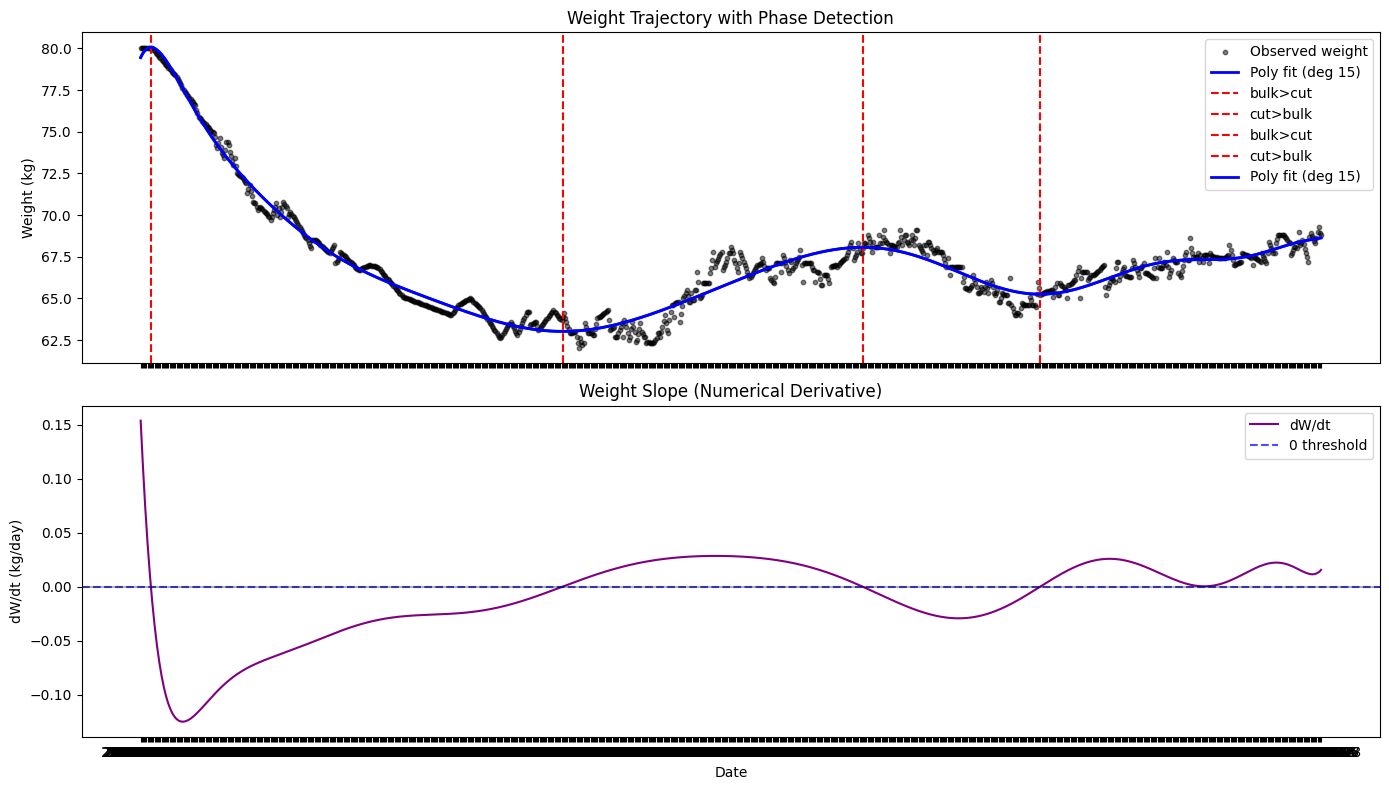

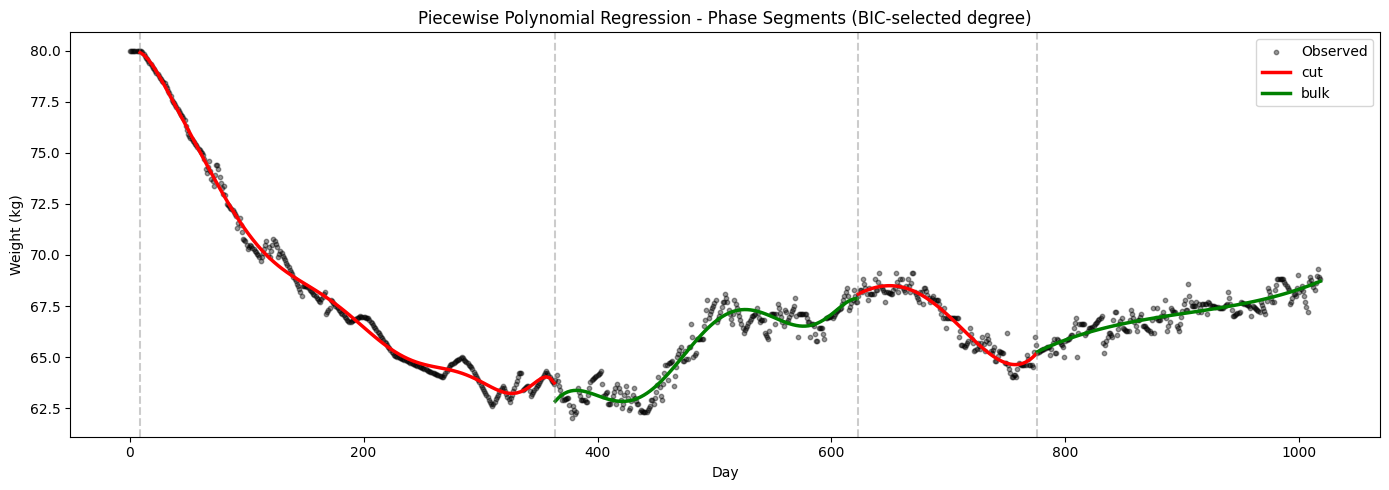

Phase  Start        End          Deg  Days     AvgSlope   Avg Intake       TDEE
cut    2023-09-23   2024-09-11   10   355       -0.0457         1690       2042
bulk   2024-09-12   2025-05-28   7    259        0.0194         2069       1919
cut    2025-05-29   2025-10-28   4    153       -0.0193         1940       2088
bulk   2025-10-29   2026-06-28   3    243        0.0143         2038       1928


In [37]:
def best_degree_for_segment(seg_days, seg_weight, max_degree):
    n = len(seg_weight)
    best_deg = 1
    best_bic = np.inf

    max_degree = min(max_degree, n - 1)  # can't fit a degree >= n points

    for deg in range(1, max_degree + 1):
        X = np.column_stack([seg_days**p for p in range(deg + 1)])
        beta = np.linalg.solve(X.T @ X, X.T @ seg_weight)
        fitted = X @ beta
        residuals = seg_weight - fitted
        sse = np.sum(residuals**2)

        if sse <= 0:
            continue  # perfect fit, avoid log(0)

        bic = n * np.log(sse / n) + deg * np.log(n)

        if bic < best_bic:
            best_bic = bic
            best_deg = deg

    return best_deg


def piecewise(df, max_degree=10):
    days = df["day"].values.astype(float)
    weight = df["Weight_linear"].values
    cals = df["Calories_linear"].values
    phases = df["phase"].values

    segments = []
    start_idx = 0

    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start_idx]:
            end_idx = i
            seg_days = days[start_idx:end_idx]
            seg_weight = weight[start_idx:end_idx]
            seg_cals = cals[start_idx:end_idx]
            phase = phases[start_idx]

            if len(seg_days) >= 10:
                degree = best_degree_for_segment(seg_days, seg_weight, max_degree=max_degree)
                X = np.column_stack([seg_days**p for p in range(degree + 1)])
                beta = np.linalg.solve(X.T @ X, X.T @ seg_weight)
                def fitted(t, beta=beta):
                    return sum(beta[p] * t**p for p in range(len(beta)))

                fitted_start = fitted(seg_days[0])
                fitted_end = fitted(seg_days[-1])
                avg_slope = (fitted_end - fitted_start) / (seg_days[-1] - seg_days[0])

                avg_intake = np.mean(seg_cals)
                tdee_estimate = avg_intake - (avg_slope * 7700)

                segments.append({
                    "start": seg_days[0],
                    "end": seg_days[-1],
                    "start_date": df["Date"].iloc[start_idx],
                    "end_date": df["Date"].iloc[end_idx - 1],
                    "phase": phase,
                    "degree": degree,
                    "beta": beta,
                    "fitted_fn": fitted,
                    "avg_slope": avg_slope,
                    "avg_intake": avg_intake,
                    "tdee_estimate": tdee_estimate,
                    "n": len(seg_days),
                    "days": seg_days,
                    "weight": seg_weight,
                })

            start_idx = i

    return segments
    
def plot_piecewise(df, segments):
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = {"bulk": "green", "cut": "red", "maintenance": "gray"}

    ax.scatter(df["day"], df["Weight_linear"], color="black", s=10, alpha=0.4, label="Observed")

    seen_labels = set()
    for seg in segments:
        t_smooth = np.linspace(seg["start"], seg["end"], 100)
        fitted_curve = seg["fitted_fn"](t_smooth)

        base_label = seg["phase"]
        label = f"{base_label}" if base_label not in seen_labels else None
        seen_labels.add(base_label)

        ax.plot(t_smooth, fitted_curve, color=colors[seg["phase"]], linewidth=2.5, label=label)
        ax.axvline(seg["start"], color="gray", linestyle="--", alpha=0.4)

    ax.set_xlabel("Day")
    ax.set_ylabel("Weight (kg)")
    ax.set_title("Piecewise Polynomial Regression - Phase Segments (BIC-selected degree)")
    ax.legend()
    plt.tight_layout()
    plt.show()

def print_segment_summary(segments):
    print(f"{'Phase':<6} {'Start':<12} {'End':<12} {'Deg':<4} {'Days':<6} {'AvgSlope':>10} {'Avg Intake':>12} {'TDEE':>10}")
    for s in segments:
        print(f"{s['phase']:<6} {s['start_date']:<12} {s['end_date']:<12} "
              f"{s['degree']:<4} {s['n']:<6} {s['avg_slope']:>10.4f} {s['avg_intake']:>12.0f} {s['tdee_estimate']:>10.0f}")
        

df1 = pd.read_csv("spline.csv")
df2, transitions = detect_phases(df1)
segments = piecewise(df2)
plot_piecewise(df2, segments)
print_segment_summary(segments)

**Fidings**

-  Linear interpolation was selected over cubic spline for filling missing weight and calorie entries, based on lower error on held-out data points.

- The numerical derivative-based phase detection identified 4 distinct bulk/cut phases across the data, with transition dates at [list dates/days].

- Piecewise polynomial regression, with degree selected independently per phase with BIC, the non-linear trend in weight within each phase shows that a polynomial regression would likely
    result in a more accurate estimation.

- Limitations of this project include the fact that weight gain could be attributed to muscle gain too, which means that the estimated TDEE should be a bit higher than it is. The fact that my TDEE is higher on a cut or weight loss phase is also consistent with my activity levels, since I tend to do more cardivascular exercise during weight loss to increase my calorie expenditure.